In [1]:
import pandas as pd
import xarray as xr
from sea_breeze.load_model_data import load_aus2200_variable, interp_model_level_to_z, load_aus2200_static, aus2200_hybrid_height_calc, load_barra_static
from sea_breeze.sea_breeze_funcs import rotate_wind
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from dask.distributed import Client
from metpy.interpolate import cross_section
import metpy.calc as mpcalc
import metpy.units as units
import numpy as np

In [2]:
client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 7
Total threads: 14,Total memory: 63.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:43969,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:43415,Total threads: 2
Dashboard: /proxy/42203/status,Memory: 9.00 GiB
Nanny: tcp://127.0.0.1:46065,


In [3]:
#Load sea breeze day dataset
region="illawara"
sb_day = pd.read_csv("/g/data/ng72/ab4502/sea_breeze_detection/barra_c_smooth_s2/sb_days/"+region+".csv")
sb_dates = pd.to_datetime(sb_day[sb_day.sb==1]["time"].values)
nonsb_dates = pd.to_datetime(sb_day[sb_day.sb==0]["time"].values)

In [4]:
#For day = d
d=-1
sb_dates[d]

Timestamp('2024-12-29 00:00:00')

In [14]:
lat_slice = slice(-36,-33)
lon_slice = slice(149,152)

barra_ts = xr.open_dataset(
    "/g/data/ob53/BARRA2/output/reanalysis/AUST-04/BOM/ERA5/historical/hres/BARRA-C2/v1/1hr/ts/latest/ts_AUST-04_ERA5_historical_hres_BOM_BARRA-C2_v1_1hr_202412-202412.nc",
    chunks={}).sel(lat=lat_slice,lon=lon_slice) - 273
orog, lsm = load_barra_static("AUST-04",lon_slice,lat_slice)

rez_shapes = xr.open_dataset("/g/data/ng72/ab4502/coastline_data/rez_coastal_shapes.nc").sel(lat=lat_slice,lon=lon_slice)

In [6]:
from rasterio import features
from affine import Affine
import geopandas as gpd

def transform_from_latlon(lat, lon):
    lat = np.asarray(lat)
    lon = np.asarray(lon)
    trans = Affine.translation(lon[0], lat[0])
    scale = Affine.scale(lon[1] - lon[0], lat[1] - lat[0])
    return trans * scale

def rasterize(shapes, coords, fill=np.nan, **kwargs):
    """Rasterize a list of (geometry, fill_value) tuples onto the given
    xray coordinates. This only works for 1d latitude and longitude
    arrays.
    """
    transform = transform_from_latlon(coords['lat'], coords['lon'])
    out_shape = (len(coords['lat']), len(coords['lon']))
    raster = features.rasterize(shapes, out_shape=out_shape,
                                fill=fill, transform=transform,
                                dtype=float, **kwargs)
    return xr.DataArray(raster, coords=coords, dims=('lat', 'lon'))

f=gpd.read_file("/g/data/ng72/ab4502/coastline_data/GCCSA_2021_AUST_SHP_GDA2020/")
shapes = [(shape, n) for n, shape in enumerate(f.geometry)]
raster = rasterize(shapes,{"lat":barra_ts.lat,"lon":barra_ts.lon},fill=np.nan)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.06/lib/python3.11/site-packages/rasterio/features.py:328: ShapeSkipWarning: Invalid or empty shape None at index 2 will not be rasterized.
  warnings.warn('Invalid or empty shape {} at index {} will not be rasterized.'.format(geom, index), ShapeSkipWarning)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.06/lib/python3.11/site-packages/rasterio/features.py:328: ShapeSkipWarning: Invalid or empty shape None at index 3 will not be rasterized.
  warnings.warn('Invalid or empty shape {} at index {} will not be rasterized.'.format(geom, index), ShapeSkipWarning)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.06/lib/python3.11/site-packages/rasterio/features.py:328: ShapeSkipWarning: Invalid or empty shape None at index 6 will not be rasterized.
  warnings.warn('Invalid or empty shape {} at index {} will not be rasterized.'.format(geom, index), ShapeSkipWarning)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.06/lib/python3

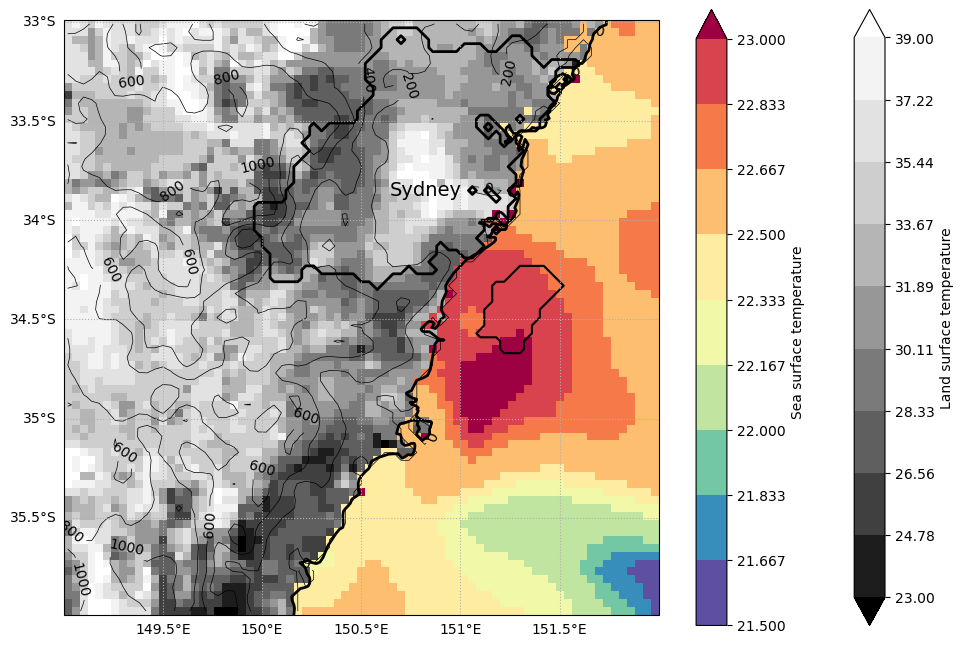

In [30]:
plt.figure(figsize=[12,8])

h=2

barra_ts_temp = barra_ts.sel(time=sb_dates[d].replace(hour=h))

ax=plt.axes(projection=ccrs.PlateCarree())

barra_ts_land = xr.where(lsm, barra_ts_temp, np.nan)
barra_ts_ocean = xr.where(lsm,np.nan,barra_ts_temp)

barra_ts_land.ts.plot(levels=np.linspace(296,312,10)-273,cmap="Greys_r",cbar_kwargs={"label":"Land surface temperature"})
barra_ts_ocean.ts.plot(levels=np.linspace(294.5,296,10)-273,cmap="Spectral_r",cbar_kwargs={"label":"Sea surface temperature"})

(rez_shapes.rez_mask==19).plot.contour(levels=1,colors="k")

(raster==0).plot.contour(levels=1,colors="k",linewidths=2)

ax.coastlines(lw=2)

plt.text(151.0057,-33.8727,"Sydney",ha="right",size=14)

c=orog.plot.contour(levels=[0,200,400,600,800,1000],colors="k",linewidths=0.5)
ax.clabel(c, inline=True, fontsize=10)

plt.title("")

ax.gridlines(ls=":",draw_labels=["left","bottom"])


# barra_uas = xr.open_dataset(
#     "/g/data/ob53/BARRA2/output/reanalysis/AUST-04/BOM/ERA5/historical/hres/BARRA-C2/v1/1hr/uas/latest/uas_AUST-04_ERA5_historical_hres_BOM_BARRA-C2_v1_1hr_202412-202412.nc",
#     chunks={}).sel(lat=lat_slice,lon=lon_slice)
# barra_vas = xr.open_dataset(
#     "/g/data/ob53/BARRA2/output/reanalysis/AUST-04/BOM/ERA5/historical/hres/BARRA-C2/v1/1hr/vas/latest/vas_AUST-04_ERA5_historical_hres_BOM_BARRA-C2_v1_1hr_202412-202412.nc",
#     chunks={}).sel(lat=lat_slice,lon=lon_slice)
# xr.Dataset({
#     "u":barra_uas.uas.sel(time=sb_dates[d].replace(hour=h)),
#     "v":barra_vas.vas.sel(time=sb_dates[d].replace(hour=h))}).coarsen({"lon":4,"lat":4},boundary="trim").mean().\
# plot.quiver(x="lon",y="lat",u="u",v="v")